In [53]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.calibration import CalibratedClassifierCV

In [ ]:
OUT_DIR = "models_by_segment"
os.makedirs(OUT_DIR, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2

In [ ]:
who_features = [
    "treatment","recency_days", "frequency", "monetary",
    "past_visit_rate", "past_conversion_rate",
    "engagement_score", "is_evening", "is_weekend",
    "hour_of_day", "day_of_week", "month",
    "f0","f1","f2","f3","f4","f5","f6","f7","f8","f9","f10","f11"
]

when_features = [
    "hour_of_day", "day_of_week", "month",
    "is_evening", "is_weekend", 
    "recency_days", "frequency", "engagement_score"
]

what_features = [
    "recency_days", "frequency", "monetary",
    "past_visit_rate", "past_conversion_rate",
    "engagement_score",
    "f0","f1","f2","f3","f4","f5","f6","f7","f8","f9","f10","f11",
    "is_evening", "is_weekend"
]

In [56]:
def make_pipeline_with_scaler(clf):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", clf)
    ])

models_def = {
    "decision_tree": lambda: make_pipeline_with_scaler(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    "random_forest": lambda: make_pipeline_with_scaler(RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)),
    "linear_svc": lambda: make_pipeline_with_scaler(
        CalibratedClassifierCV(
            estimator=LinearSVC(max_iter=5000, random_state=RANDOM_STATE),
            cv=3,
            method="sigmoid"
        )
    ),
    "gradient_boosting": lambda: make_pipeline_with_scaler(GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE))
}

In [38]:
df = pd.read_csv("df_segmented.csv")

In [ ]:
if "treatment_type" not in df.columns:
    raise ValueError("df must contain 'treatment_type' column for WHAT task.")

le_treatment = LabelEncoder()
df["treatment_encoded"] = le_treatment.fit_transform(df["treatment_type"])

joblib.dump(le_treatment, os.path.join(OUT_DIR, "label_encoder_treatment.joblib"))

['models_by_segment\\label_encoder_treatment.joblib']

In [ ]:
segment_models = {}

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import auc

def compute_qini_curve(df, uplift_col="uplift", treatment_col="treatment", outcome_col="visit"):
    df_sorted = df.sort_values(by=uplift_col, ascending=False).reset_index(drop=True)

    df_sorted["cum_treat"] = (df_sorted[treatment_col] == 1).cumsum()
    df_sorted["cum_control"] = (df_sorted[treatment_col] == 0).cumsum()

    df_sorted["cum_y_treat"] = ((df_sorted[treatment_col] == 1) & (df_sorted[outcome_col] == 1)).cumsum()
    df_sorted["cum_y_control"] = ((df_sorted[treatment_col] == 0) & (df_sorted[outcome_col] == 1)).cumsum()

    df_sorted["qini"] = (df_sorted["cum_y_treat"] / df_sorted["cum_treat"].max()) - \
                        (df_sorted["cum_y_control"] / df_sorted["cum_control"].max())

    return df_sorted, df_sorted["qini"]


def compute_auuc(df_sorted, qini_curve):
    x = np.arange(len(qini_curve))
    return auc(x, qini_curve)


def compute_uplift_gain(df, uplift_col="uplift"):
    cutoff = int(0.1 * len(df))
    top_group = df.sort_values(by=uplift_col, ascending=False).head(cutoff)
    return top_group[uplift_col].mean()


In [ ]:
segments = df["segment_id"].unique()
print(f"Found segments: {segments}")
print(f"Will train {len(segments)} segments × 3 tasks × 4 models = {len(segments)*12} models")

for seg in segments:
    print("\n" + "="*60)
    print(f"Training segment: {seg}")
    seg_df = df[df["segment_id"] == seg].copy()
    if seg_df.shape[0] < 50:
        print(f"  WARNING: Segment {seg} has very few rows ({seg_df.shape[0]}). Models may overfit.")
    
    segment_models[seg] = {"who": {}, "what": {}, "when": {}}

    print(f"\nWHO (Uplift Modeling) for Segment {seg}")

    target_who = "visit"

    treated_df = seg_df[seg_df["treatment"] == 1]
    control_df = seg_df[seg_df["treatment"] == 0]

    X_T = treated_df[who_features].fillna(0)
    y_T = treated_df[target_who].astype(int)

    X_C = control_df[who_features].fillna(0)
    y_C = control_df[target_who].astype(int)

    segment_models[seg]["who"] = {}

    for model_name, model_ctor in models_def.items():

        print(f"  [WHO] Training T-Learner → {model_name}")

        model_T = model_ctor()
        try:
            model_T.fit(X_T, y_T)
        except Exception as e:
            print(f"    ERROR in T-model for {model_name}: {e}")
            continue

        model_C = model_ctor()
        try:
            model_C.fit(X_C, y_C)
        except Exception as e:
            print(f"    ERROR in C-model for {model_name}: {e}")
            continue


        X_all = seg_df[who_features].fillna(0)
        prob_T = model_T.predict_proba(X_all)[:, 1]
        prob_C = model_C.predict_proba(X_all)[:, 1]

        uplift = prob_T - prob_C
        seg_df[f"uplift_{model_name}"] = uplift


        uplift_df_sorted, qini_curve = compute_qini_curve(
            seg_df,
            uplift_col=f"uplift_{model_name}",
            treatment_col="treatment",
            outcome_col="visit"
        )

        auuc_val = compute_auuc(qini_curve)
        uplift_gain = compute_uplift_gain(seg_df, uplift_col=f"uplift_{model_name}")

        metrics = {
            "AUUC": round(auuc_val, 4),
            "Qini_max": round(qini_curve.max(), 4),
            "Uplift_Gain@10%": round(uplift_gain, 4)
        }

        print(f"    AUUC = {metrics['AUUC']}")
        print(f"    Qini_max = {metrics['Qini_max']}")
        print(f"    Gain@10% = {metrics['Uplift_Gain@10%']}")


        fname = os.path.join(OUT_DIR, f"seg_{seg}__who__{model_name}__T.joblib")
        joblib.dump(model_T, fname)

        fname = os.path.join(OUT_DIR, f"seg_{seg}__who__{model_name}__C.joblib")
        joblib.dump(model_C, fname)


        segment_models[seg]["who"][model_name] = {
            "T_model": model_T,
            "C_model": model_C,
            "metrics": metrics
        }


    df.loc[seg_df.index, seg_df.filter(regex="uplift_").columns] = \
        seg_df.filter(regex="uplift_")



    target_when = "visit"
    X = seg_df[when_features].fillna(0)
    y = seg_df[target_when].astype(int).fillna(0)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y if y.nunique()>1 else None)

    for model_name, model_ctor in models_def.items():
        print(f"  [WHEN] Training {model_name} ...")
        clf = model_ctor()
        try:
            clf.fit(X_train, y_train)
        except Exception as e:
            print(f"    ERROR training WHEN {model_name} on segment {seg}: {e}")
            continue

        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"    WHEN {model_name} accuracy: {acc:.4f}")

        segment_models[seg]["when"][model_name] = {"model": clf, "metrics": {"accuracy": acc}}
        fname = os.path.join(OUT_DIR, f"seg_{seg}__when__{model_name}.joblib")
        joblib.dump(clf, fname)


    target_what = "treatment_encoded"
    X = seg_df[what_features].fillna(0)
    y = seg_df[target_what].astype(int).fillna(0)


    if y.nunique() < 2:
        print(f"  [WHAT] Segment {seg} has only one treatment class; skipping WHAT models.")
    else:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

        for model_name, model_ctor in models_def.items():
            print(f"  [WHAT] Training {model_name} ...")
            clf = model_ctor()
            try:
                clf.fit(X_train, y_train)
            except Exception as e:
                print(f"    ERROR training WHAT {model_name} on segment {seg}: {e}")
                continue

            y_pred = clf.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            print(f"    WHAT {model_name} accuracy: {acc:.4f}")


            info = {"model": clf, "metrics": {"accuracy": acc}, "label_encoder": "label_encoder_treatment.joblib"}
            segment_models[seg]["what"][model_name] = info

            fname = os.path.join(OUT_DIR, f"seg_{seg}__what__{model_name}.joblib")
            joblib.dump(clf, fname)



    print(f"Segment {seg} Performance Summary")


    who_rows = []
    for model_name, data in segment_models[seg]["who"].items():
        who_rows.append({
            "Model": model_name,
            "AUUC": data["metrics"]["AUUC"],
            "Qini(Max)": data["metrics"]["Qini_max"],
            "Gain@10%": data["metrics"]["Uplift_Gain@10%"]
        })

    who_df = pd.DataFrame(who_rows)
    print("WHO (Uplift Models):")
    print(who_df.to_string(index=False))
    print("\n")



    what_rows = []
    for model_name, data in segment_models[seg]["what"].items():
        what_rows.append({
            "Model": model_name,
            "Accuracy": data["metrics"]["accuracy"]
        })

    what_df = pd.DataFrame(what_rows)
    print("WHAT (Treatment Recommendation Models):")
    print(what_df.to_string(index=False))
    print("\n")



    when_rows = []
    for model_name, data in segment_models[seg]["when"].items():
        when_rows.append({
            "Model": model_name,
            "Accuracy": data["metrics"]["accuracy"]
        })

    when_df = pd.DataFrame(when_rows)
    print("WHEN (Time Optimization Models):")
    print(when_df.to_string(index=False))
    



Found segments: [0 4 2 1 6 5 3]
Will train 7 segments × 3 tasks × 4 models = 84 models

Training segment: 0

--- WHO (Uplift Modeling) for Segment 0 ---
  [WHO] Training T-Learner → decision_tree


    AUUC = 2744.5974
    Qini_max = 0.1445
    Gain@10% = 1.0
  [WHO] Training T-Learner → random_forest
    AUUC = 4860.8455
    Qini_max = 0.2949
    Gain@10% = 0.5091
  [WHO] Training T-Learner → linear_svc


C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The defaul

    AUUC = 1036.1886
    Qini_max = 0.0585
    Gain@10% = 0.1533
  [WHO] Training T-Learner → gradient_boosting
    AUUC = 2231.6918
    Qini_max = 0.1218
    Gain@10% = 0.2753
  [WHEN] Training decision_tree ...
    WHEN decision_tree accuracy: 0.5932
  [WHEN] Training random_forest ...
    WHEN random_forest accuracy: 0.6945
  [WHEN] Training linear_svc ...


C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


...

    AUUC = 314.8297
    Qini_max = 0.0689
    Gain@10% = 0.1563
  [WHO] Training T-Learner → gradient_boosting
    AUUC = 1212.2488
    Qini_max = 0.2744
    Gain@10% = 0.4638
  [WHEN] Training decision_tree ...
    WHEN decision_tree accuracy: 0.6033
  [WHEN] Training random_forest ...
    WHEN random_forest accuracy: 0.7239
  [WHEN] Training linear_svc ...


C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


    WHEN linear_svc accuracy: 0.7395
  [WHEN] Training gradient_boosting ...
    WHEN gradient_boosting accuracy: 0.7380
  [WHAT] Training decision_tree ...
    WHAT decision_tree accuracy: 0.2361
  [WHAT] Training random_forest ...
    WHAT random_forest accuracy: 0.3168
  [WHAT] Training linear_svc ...


C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The defaul

    WHAT linear_svc accuracy: 0.3449
  [WHAT] Training gradient_boosting ...
    WHAT gradient_boosting accuracy: 0.3072


==================== SEGMENT SUMMARY ====================
Segment 3 — Performance Summary

WHO (Uplift Models):
            Model      AUUC  Qini(Max)  Gain@10%
    decision_tree  968.4502     0.1839    1.0000
    random_forest 2118.9294     0.6742    0.4480
       linear_svc  314.8297     0.0689    0.1563
gradient_boosting 1212.2488     0.2744    0.4638


WHAT (Treatment Recommendation Models):
            Model  Accuracy
    decision_tree  0.236121
    random_forest  0.316802
       linear_svc  0.344930
gradient_boosting  0.307180


WHEN (Time Optimization Models):
            Model  Accuracy
    decision_tree  0.603257
    random_forest  0.723908
       linear_svc  0.739452
gradient_boosting  0.737972




In [58]:
meta_fname = os.path.join(OUT_DIR, "segment_models_index.joblib")
joblib.dump(segment_models, meta_fname)

['models_by_segment\\segment_models_index.joblib']

In [ ]:
print("\nModels saved to:", OUT_DIR)
print("Label encoder saved: label_encoder_treatment.joblib")
print("Saved metadata index:", meta_fname)


All done. Models saved to: models_by_segment
Label encoder saved: label_encoder_treatment.joblib
Saved metadata index: models_by_segment\segment_models_index.joblib


In [ ]:
def generate_recommendations(df, segment_models, le_treatment):

    results = []

    for idx, row in df.iterrows():

        customer_id = row["customer_id"]
        seg = row["segment_id"]

        models = segment_models[seg]


        who_models_seg = models["who"]["gradient_boosting"]
        T_model = who_models_seg["T_model"]
        C_model = who_models_seg["C_model"]

        X_who = row[who_features].values.reshape(1, -1)

        prob_T = T_model.predict_proba(X_who)[0][1]

        prob_C = C_model.predict_proba(X_who)[0][1]

        uplift = prob_T - prob_C
        recommended_flag = "Yes" if uplift > 0 else "No"


        what_model = models["what"]["gradient_boosting"]["model"]
        X_what = row[what_features].values.reshape(1, -1)
        treat_pred = what_model.predict(X_what)[0]
        best_treatment = le_treatment.inverse_transform([treat_pred])[0]


        when_model = models["when"]["gradient_boosting"]["model"]

        candidate_times = {
            "morning": 8,
            "afternoon": 14,
            "evening": 20,
            "night": 1
        }

        best_time = None
        best_prob = -1

        for name, hour in candidate_times.items():
            test_row = row.copy()
            test_row["hour_of_day"] = hour
            X_when = test_row[when_features].values.reshape(1, -1)
            prob = when_model.predict_proba(X_when)[0][1]

            if prob > best_prob:
                best_prob = prob
                best_time = name

        
        results.append({
            "customer_id": customer_id,
            "segment": seg,
            "best_treatment": best_treatment,
            "best_time": best_time,
            "uplift_score": round(uplift, 4),
            "recommended": recommended_flag
        })

    return pd.DataFrame(results)


In [ ]:
final_output = generate_recommendations(df.head(5), segment_models, le_treatment) 
print(final_output)


  customer_id  segment     best_treatment  best_time  uplift_score recommended
0    C0056423        0       discount_10%    evening        0.2153         Yes
1    C0015796        4       discount_20%    morning        0.0020         Yes
2    C0000861        0              email    evening       -0.0373          No
3    C0038159        2              email  afternoon       -0.3889          No
4    C0054344        1  push_notification    evening        0.0173         Yes


C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\a


 Plotting AUUC for Segment 0, Model: decision_tree



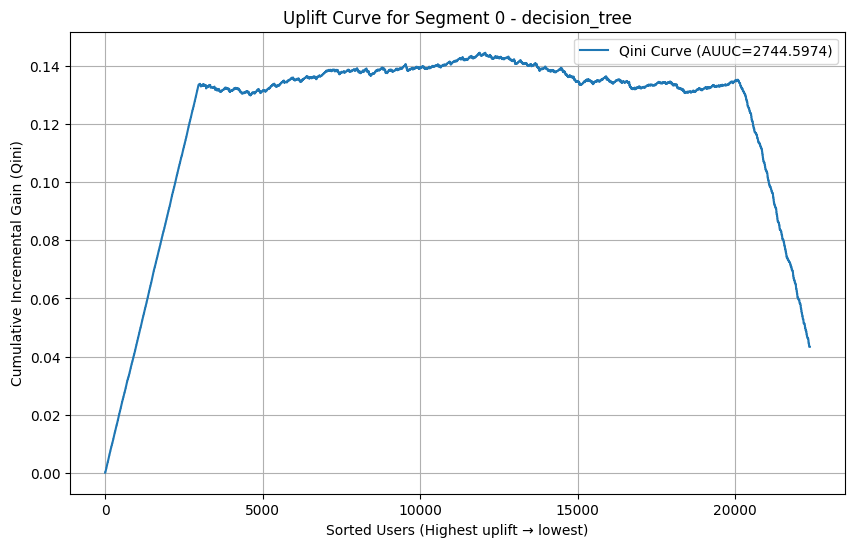

Segment 0 | Model decision_tree | AUUC = 2744.5974

 Plotting AUUC for Segment 0, Model: random_forest



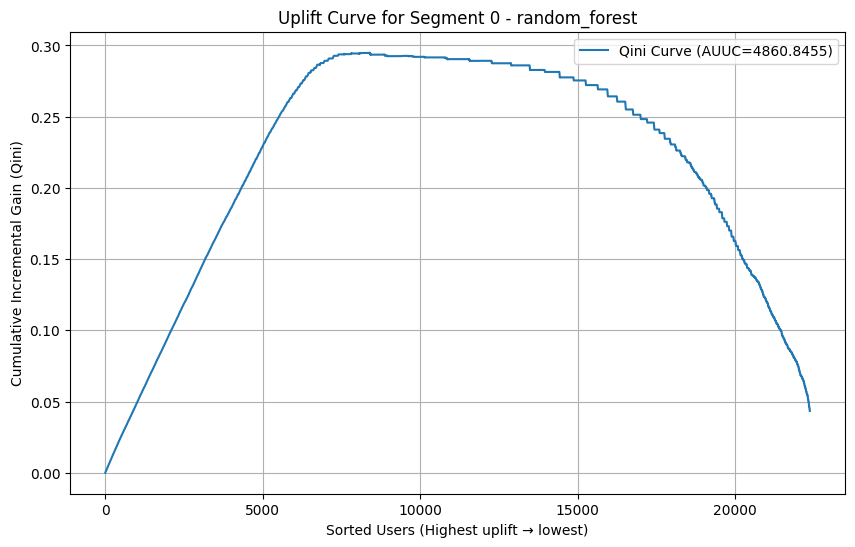

Segment 0 | Model random_forest | AUUC = 4860.8455

 Plotting AUUC for Segment 0, Model: linear_svc



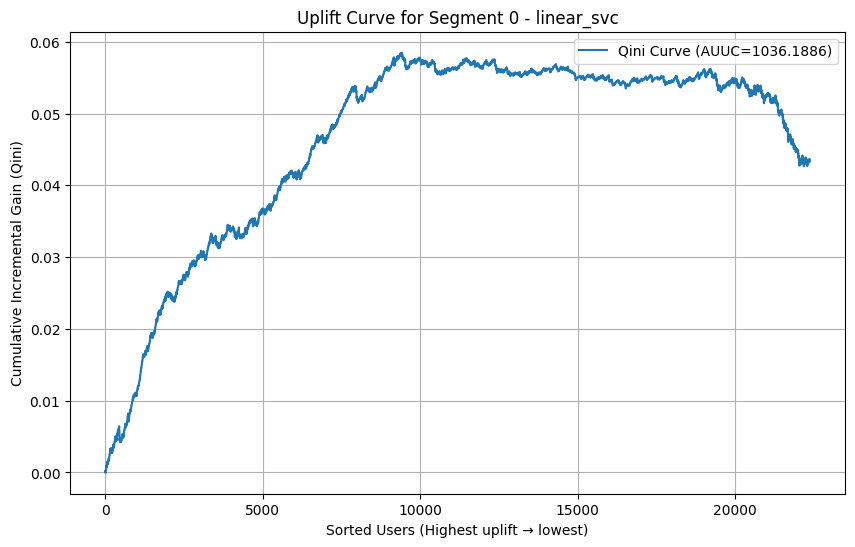

Segment 0 | Model linear_svc | AUUC = 1036.1886

 Plotting AUUC for Segment 0, Model: gradient_boosting



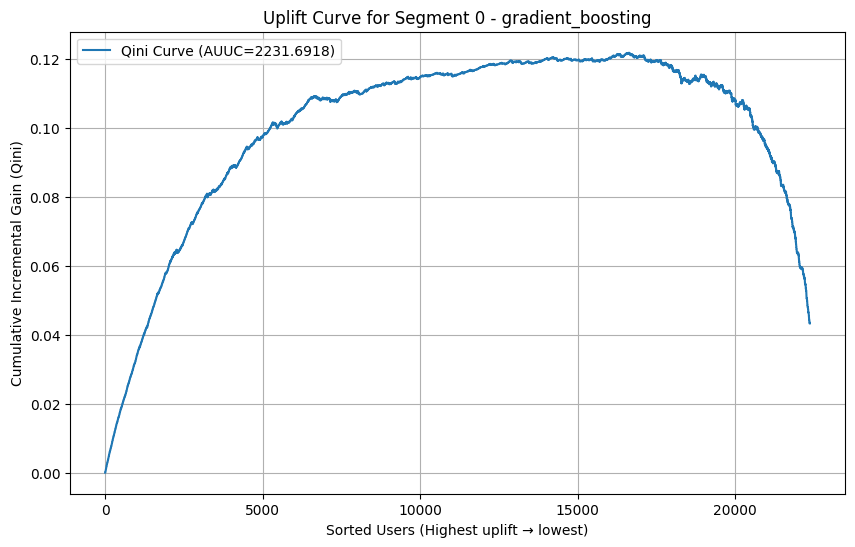

Segment 0 | Model gradient_boosting | AUUC = 2231.6918

 Plotting AUUC for Segment 4, Model: decision_tree



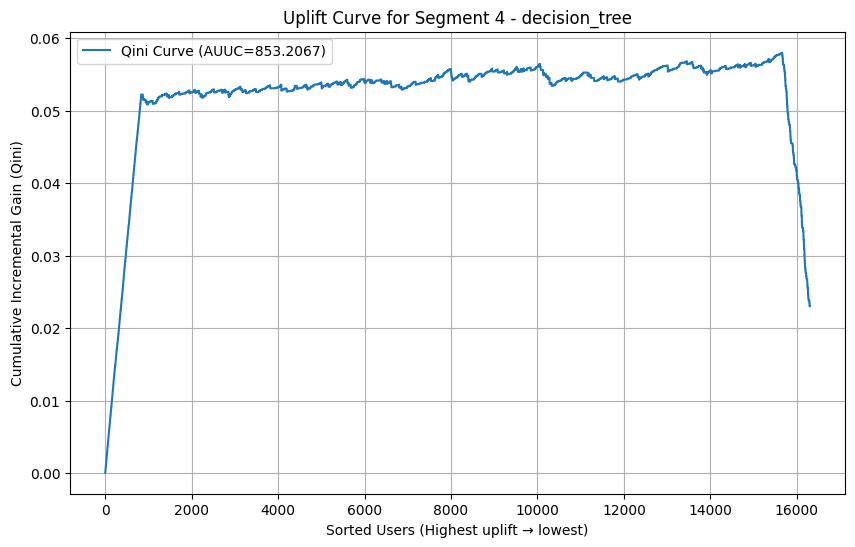

Segment 4 | Model decision_tree | AUUC = 853.2067

 Plotting AUUC for Segment 4, Model: random_forest



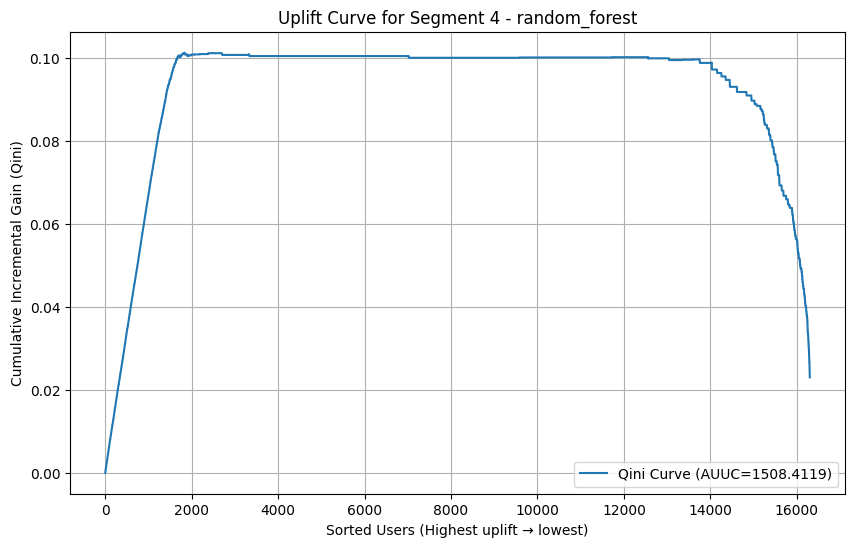

Segment 4 | Model random_forest | AUUC = 1508.4119

 Plotting AUUC for Segment 4, Model: linear_svc



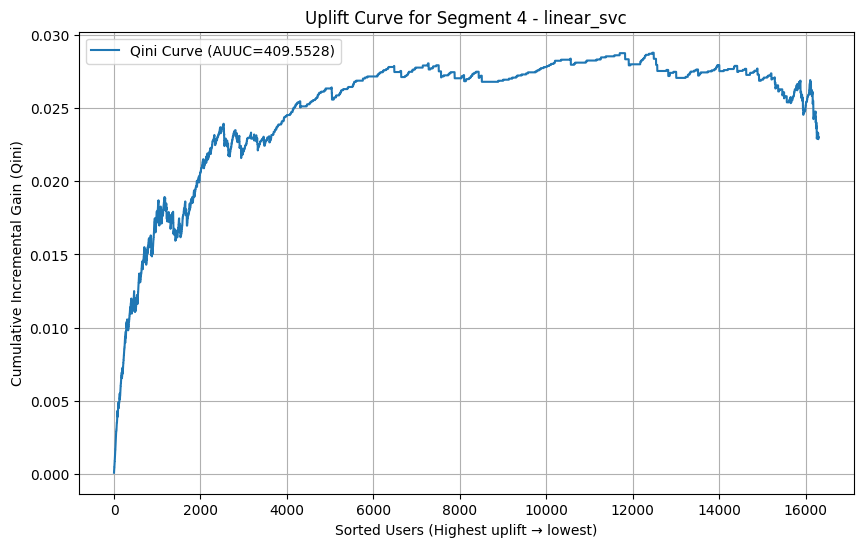

Segment 4 | Model linear_svc | AUUC = 409.5528

 Plotting AUUC for Segment 4, Model: gradient_boosting



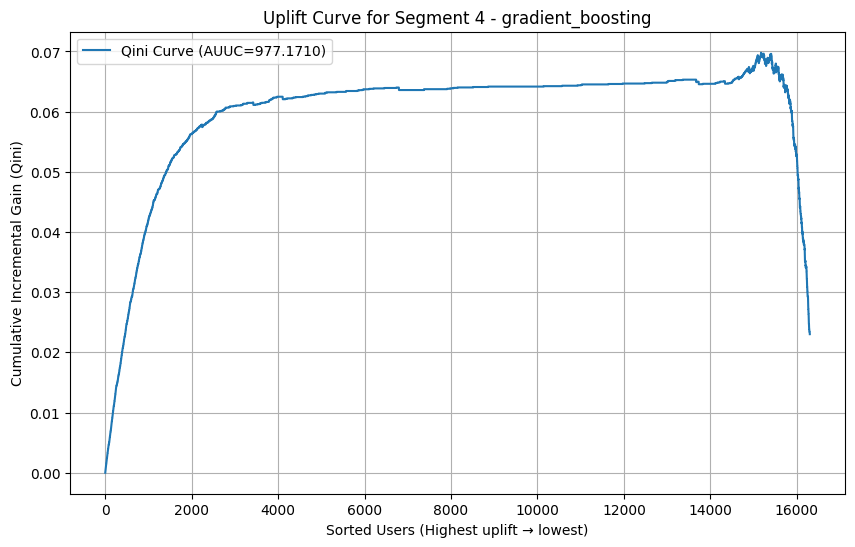

Segment 4 | Model gradient_boosting | AUUC = 977.1710

 Plotting AUUC for Segment 2, Model: decision_tree



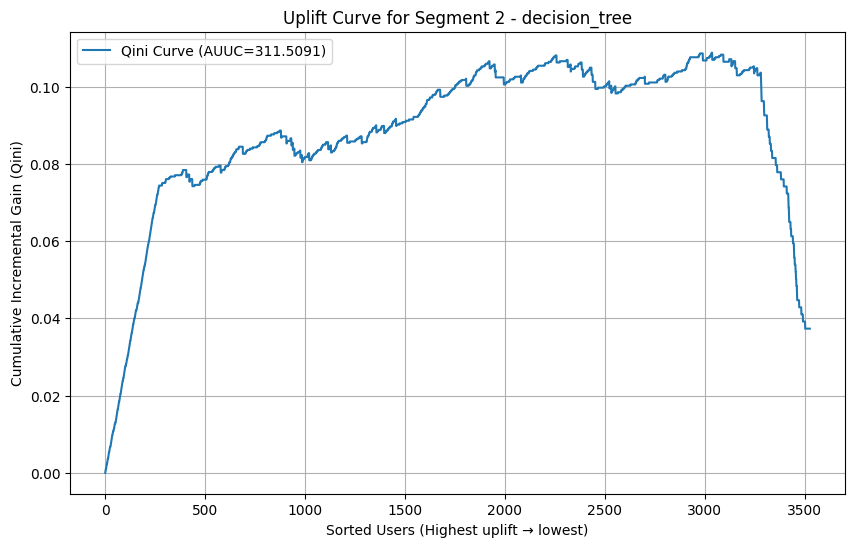

Segment 2 | Model decision_tree | AUUC = 311.5091

 Plotting AUUC for Segment 2, Model: random_forest



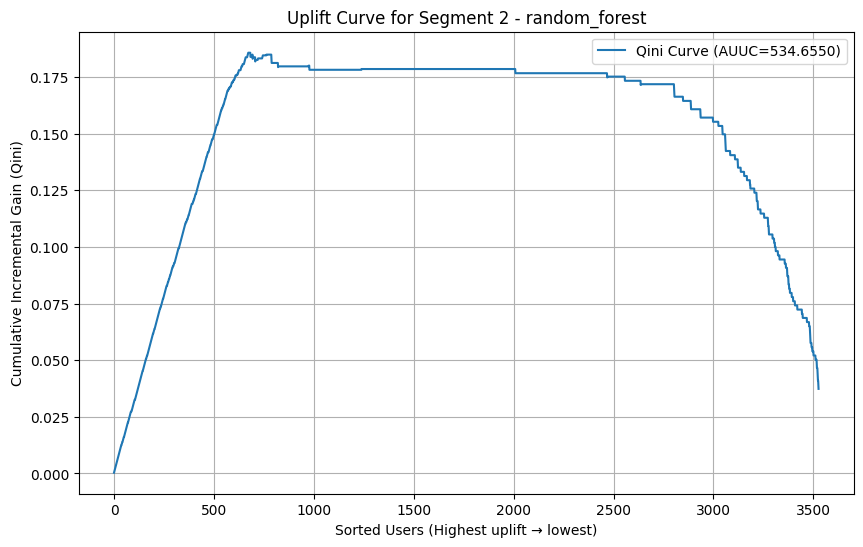

Segment 2 | Model random_forest | AUUC = 534.6550

 Plotting AUUC for Segment 2, Model: linear_svc



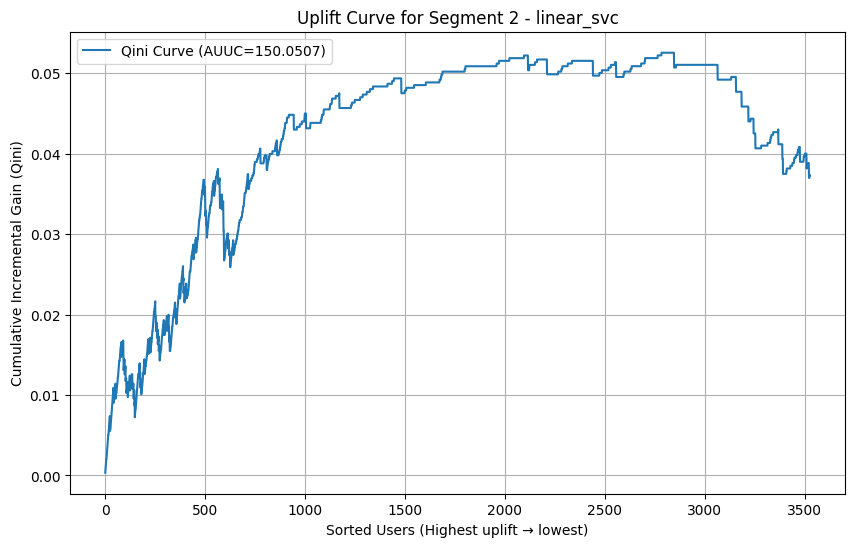

Segment 2 | Model linear_svc | AUUC = 150.0507

 Plotting AUUC for Segment 2, Model: gradient_boosting



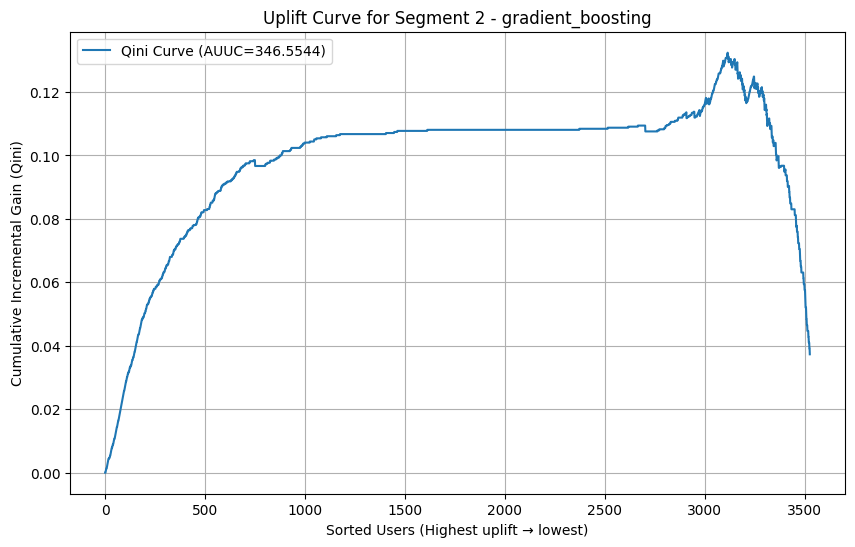

Segment 2 | Model gradient_boosting | AUUC = 346.5544

 Plotting AUUC for Segment 1, Model: decision_tree



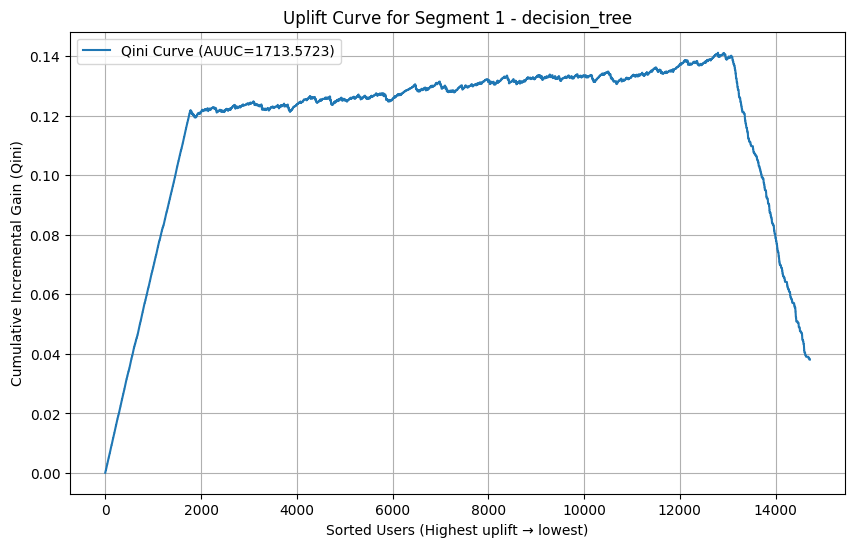

Segment 1 | Model decision_tree | AUUC = 1713.5723

 Plotting AUUC for Segment 1, Model: random_forest



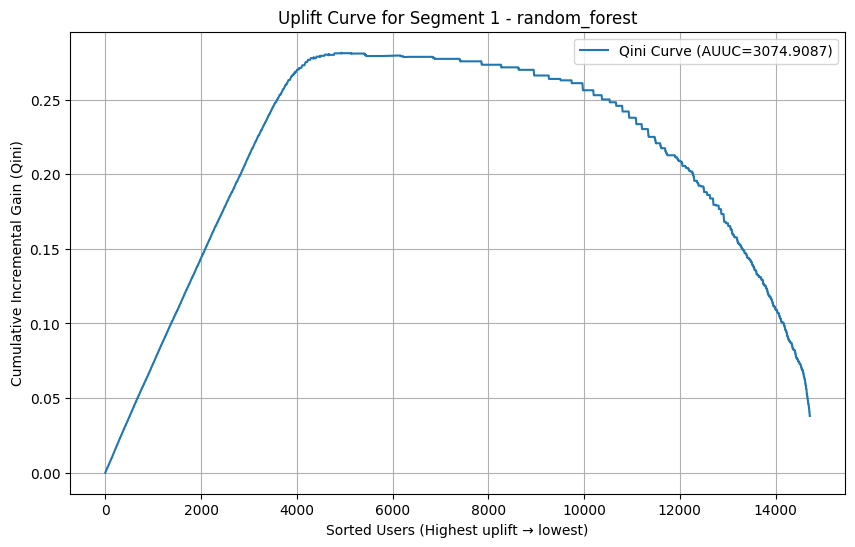

Segment 1 | Model random_forest | AUUC = 3074.9087

 Plotting AUUC for Segment 1, Model: linear_svc



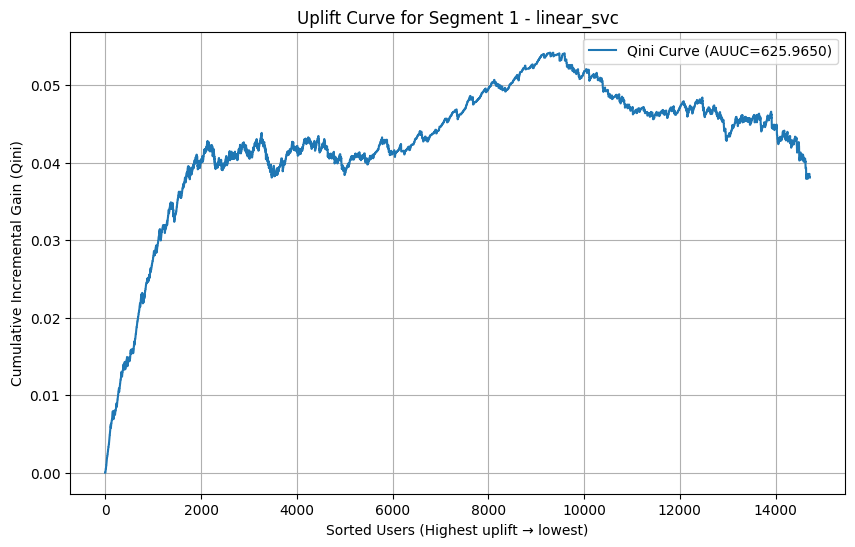

Segment 1 | Model linear_svc | AUUC = 625.9650

 Plotting AUUC for Segment 1, Model: gradient_boosting



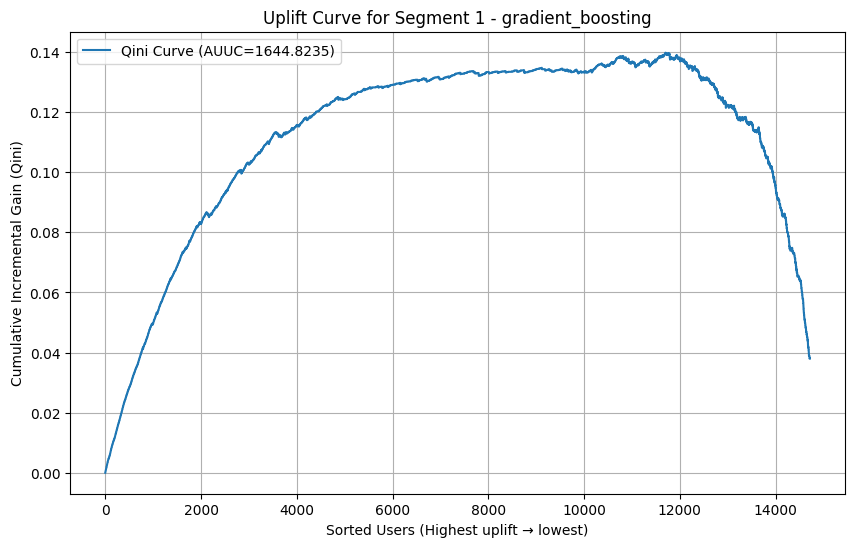

Segment 1 | Model gradient_boosting | AUUC = 1644.8235

 Plotting AUUC for Segment 6, Model: decision_tree



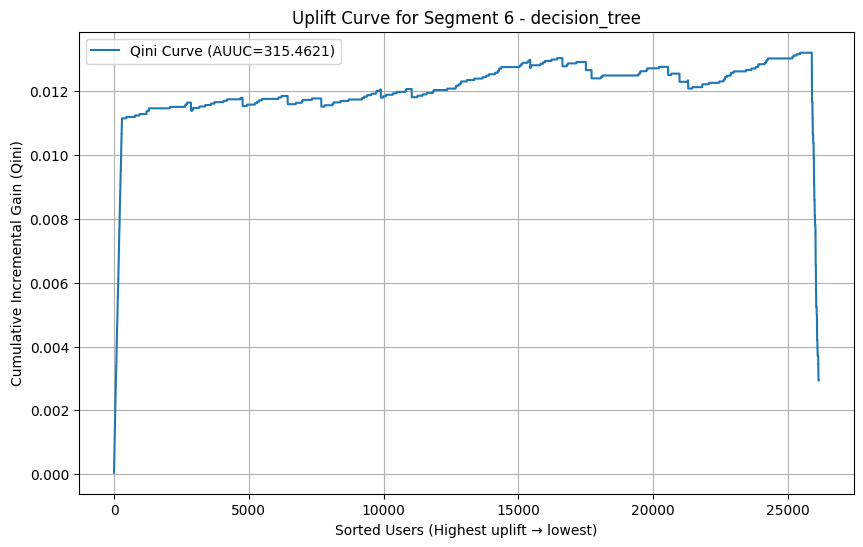

Segment 6 | Model decision_tree | AUUC = 315.4621

 Plotting AUUC for Segment 6, Model: random_forest



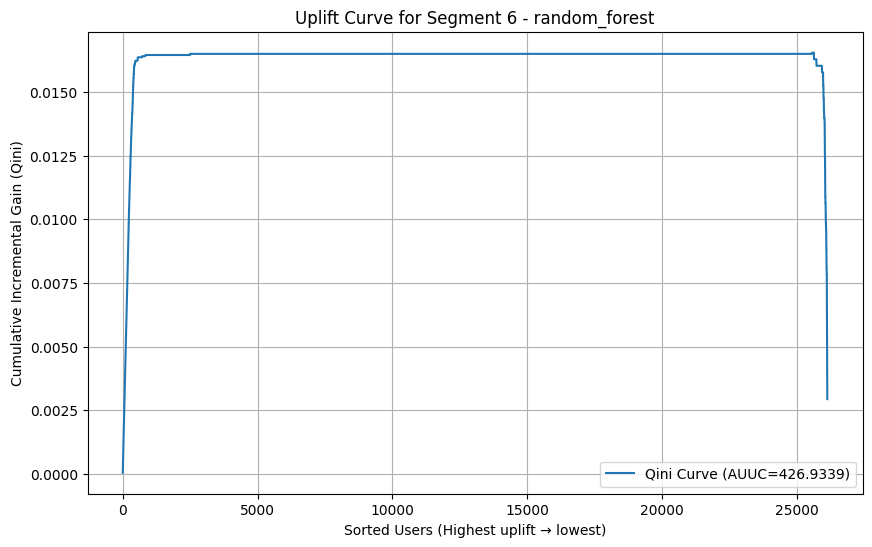

Segment 6 | Model random_forest | AUUC = 426.9339

 Plotting AUUC for Segment 6, Model: linear_svc



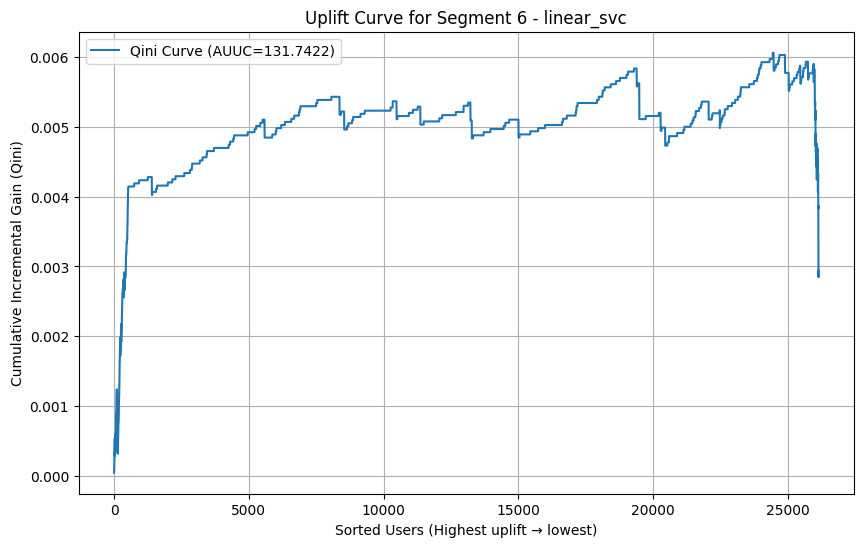

Segment 6 | Model linear_svc | AUUC = 131.7422

 Plotting AUUC for Segment 6, Model: gradient_boosting



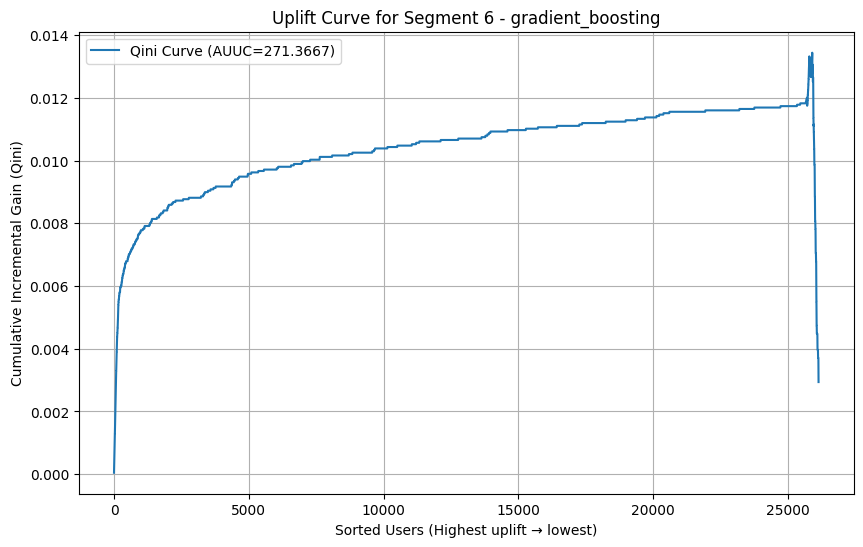

Segment 6 | Model gradient_boosting | AUUC = 271.3667

 Plotting AUUC for Segment 5, Model: decision_tree



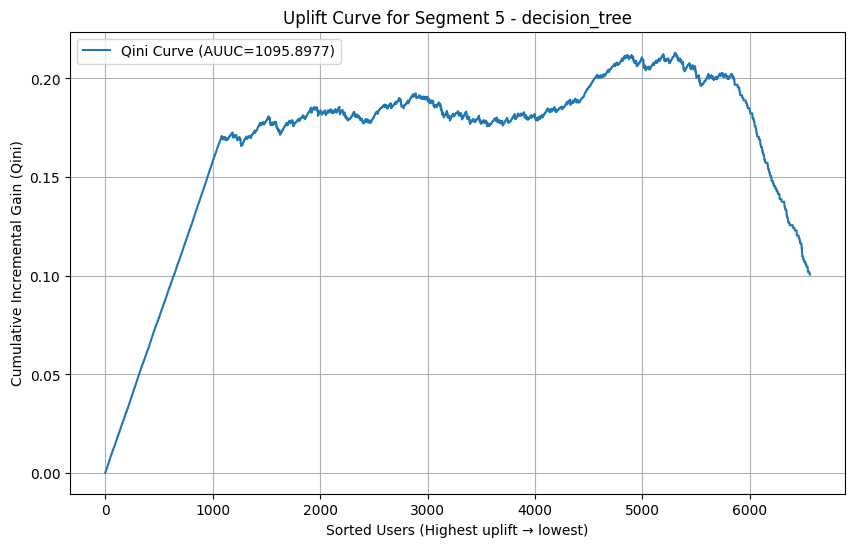

Segment 5 | Model decision_tree | AUUC = 1095.8977

 Plotting AUUC for Segment 5, Model: random_forest



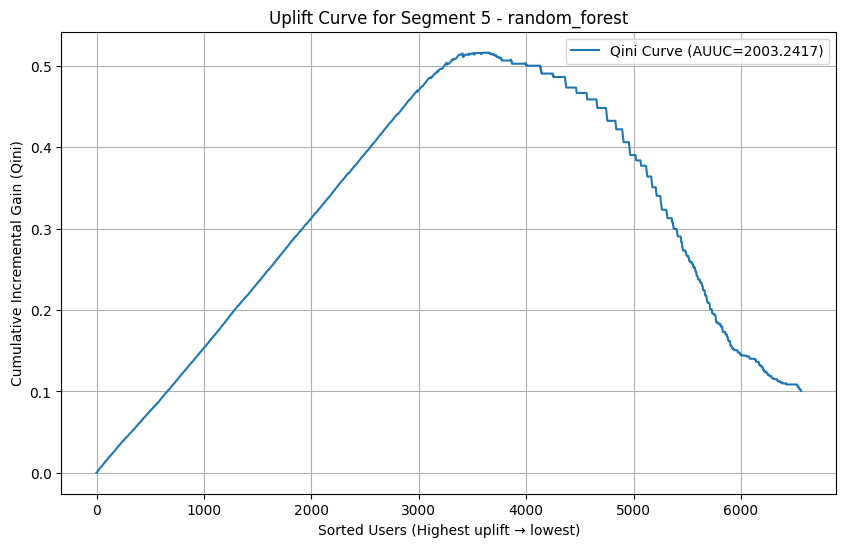

Segment 5 | Model random_forest | AUUC = 2003.2417

 Plotting AUUC for Segment 5, Model: linear_svc



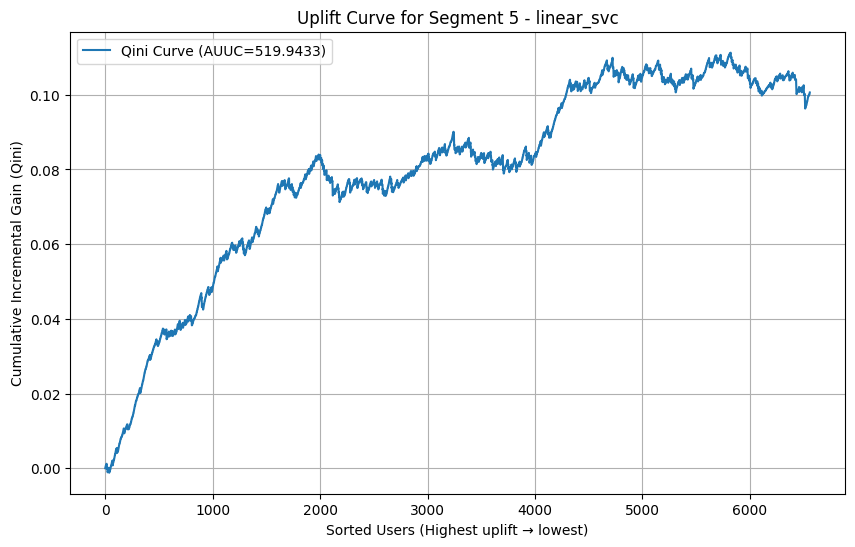

Segment 5 | Model linear_svc | AUUC = 519.9433

 Plotting AUUC for Segment 5, Model: gradient_boosting



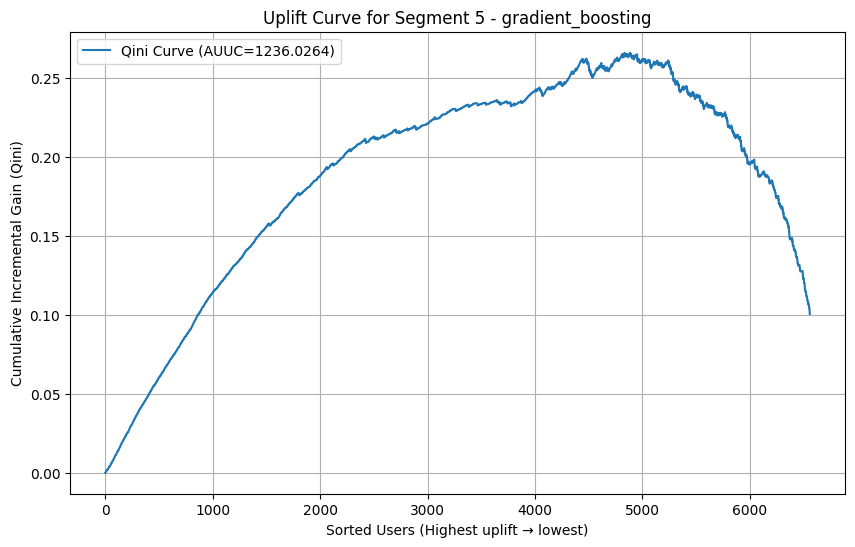

Segment 5 | Model gradient_boosting | AUUC = 1236.0264

 Plotting AUUC for Segment 3, Model: decision_tree



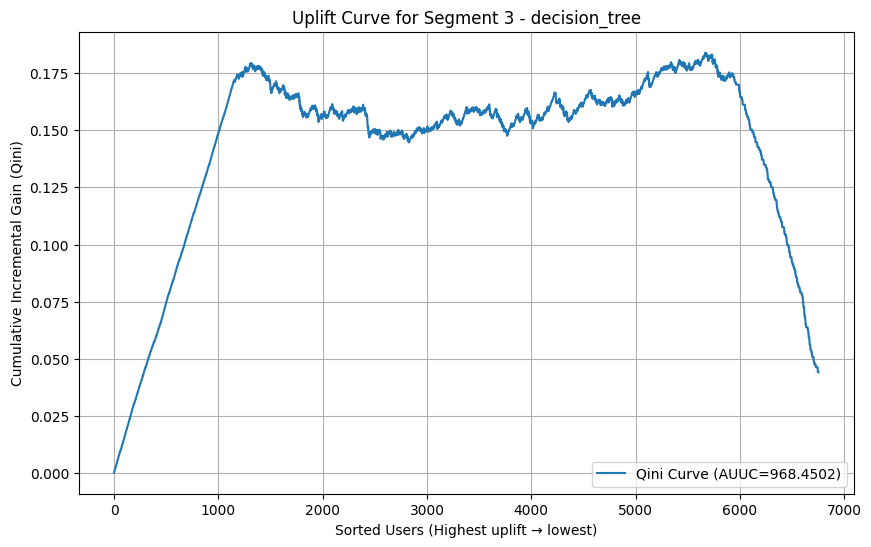

Segment 3 | Model decision_tree | AUUC = 968.4502

 Plotting AUUC for Segment 3, Model: random_forest



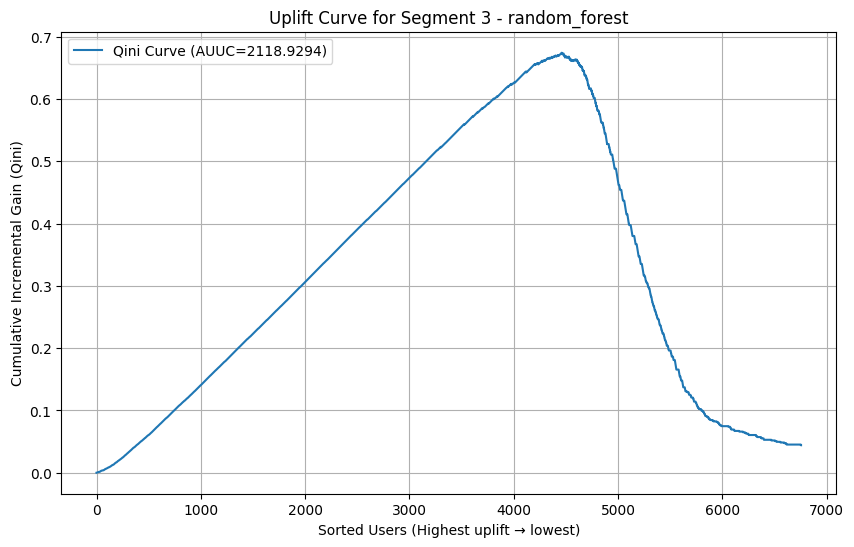

Segment 3 | Model random_forest | AUUC = 2118.9294

 Plotting AUUC for Segment 3, Model: linear_svc



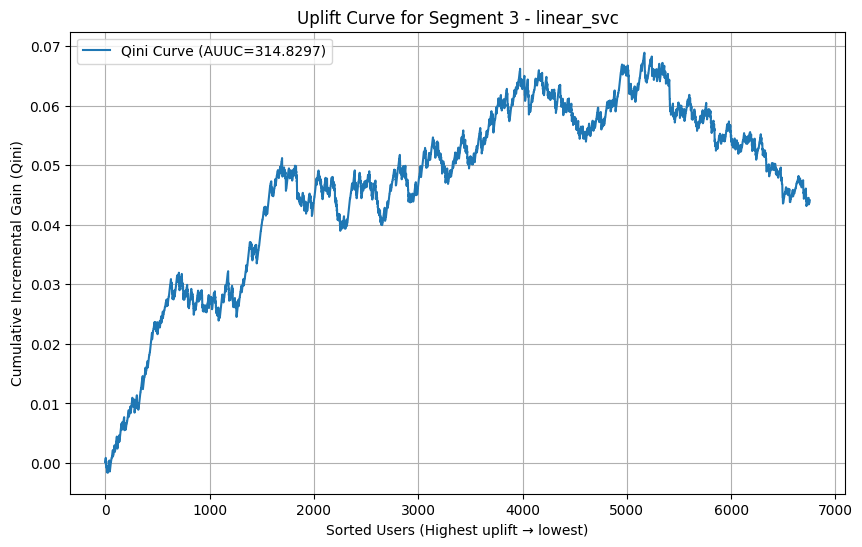

Segment 3 | Model linear_svc | AUUC = 314.8297

 Plotting AUUC for Segment 3, Model: gradient_boosting



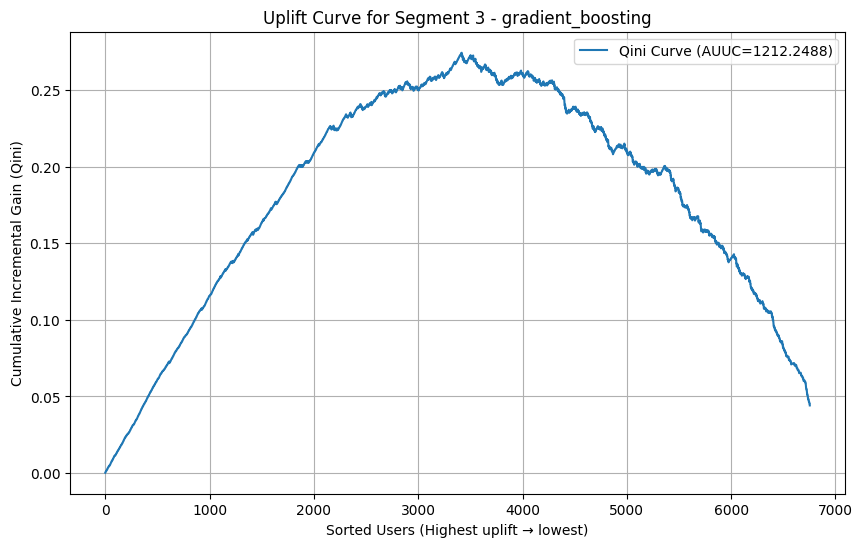

Segment 3 | Model gradient_boosting | AUUC = 1212.2488


In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import auc


def compute_qini_curve(df, uplift_col="uplift", treatment_col="treatment", outcome_col="visit"):

    df_sorted = df.sort_values(by=uplift_col, ascending=False).reset_index(drop=True)

    df_sorted["cum_treat"] = (df_sorted[treatment_col] == 1).cumsum()
    df_sorted["cum_control"] = (df_sorted[treatment_col] == 0).cumsum()

    df_sorted["cum_y_treat"] = ((df_sorted[treatment_col] == 1) &
                                (df_sorted[outcome_col] == 1)).cumsum()
    df_sorted["cum_y_control"] = ((df_sorted[treatment_col] == 0) &
                                  (df_sorted[outcome_col] == 1)).cumsum()

    df_sorted["qini"] = (df_sorted["cum_y_treat"] / df_sorted["cum_treat"].max()) - \
                        (df_sorted["cum_y_control"] / df_sorted["cum_control"].max())

    return df_sorted, df_sorted["qini"]


def plot_auuc(df_sorted, qini_curve, seg, model_name):
    x = np.arange(len(qini_curve))
    auuc = auc(x, qini_curve)

    plt.figure(figsize=(10,6))
    plt.plot(x, qini_curve, label=f"Qini Curve (AUUC={auuc:.4f})")
    plt.title(f"Uplift Curve for Segment {seg} - {model_name}")
    plt.xlabel("Sorted Users (Highest uplift → lowest)")
    plt.ylabel("Cumulative Incremental Gain (Qini)")
    plt.grid(True)
    plt.legend()
    plt.show()

    return auuc



def compute_and_plot_auuc_for_segment(seg, model_name, df_segment):

    T_model = joblib.load(f"models_by_segment/seg_{seg}__who__{model_name}__T.joblib")
    C_model = joblib.load(f"models_by_segment/seg_{seg}__who__{model_name}__C.joblib")

    X_all = df_segment[who_features].fillna(0)

    prob_T = T_model.predict_proba(X_all)[:, 1]
    prob_C = C_model.predict_proba(X_all)[:, 1]
    df_segment[f"uplift_{model_name}"] = prob_T - prob_C

    df_sorted, qini_curve = compute_qini_curve(
        df_segment,
        uplift_col=f"uplift_{model_name}",
        treatment_col="treatment",
        outcome_col="visit"
    )

    auuc_val = plot_auuc(df_sorted, qini_curve, seg, model_name)
    print(f"Segment {seg} | Model {model_name} | AUUC = {auuc_val:.4f}")


for seg in df["segment_id"].unique():

    df_segment = df[df["segment_id"] == seg].copy()

    model_name = ["decision_tree","random_forest","linear_svc","gradient_boosting"]

    for m_name in model_name:
        print(f" Plotting AUUC for Segment {seg}, Model: {m_name}")
        compute_and_plot_auuc_for_segment(seg, m_name, df_segment)

